# PointNet and a little bit of Vector Neurons

The first part of seminar is an implementation of [PointNet: Deep Learning on Point Sets for 3D Classification and Segmentation](https://arxiv.org/abs/1612.00593) using PyTorch.

The second part of seminar is an implementation of different layers from [Vector Neurons: A General Framework for SO(3)-Equivariant Networks](https://arxiv.org/abs/2104.12229) using PyTorch.

The part of the seminar is taken from this [source](https://colab.research.google.com/github/nikitakaraevv/pointnet/blob/master/nbs/PointNetClass.ipynb#scrollTo=TXEzgwr_Mfc0).

## Getting started

In [1]:
import os
import math
import random
import numpy as np
from tqdm.auto import tqdm
import scipy.spatial.distance
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

# Data preparation

### Frirst steps with data

Let's firstly dowload data. It comprises 10 categories, 3,991 models for training and 908 for testing.

In [3]:
!wget http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
!unzip -q ModelNet10.zip

data_path = "/content/ModelNet10"

--2026-02-19 11:19:43--  http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
Resolving 3dvision.princeton.edu (3dvision.princeton.edu)... 128.112.136.67
Connecting to 3dvision.princeton.edu (3dvision.princeton.edu)|128.112.136.67|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip [following]
--2026-02-19 11:19:43--  https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
Connecting to 3dvision.princeton.edu (3dvision.princeton.edu)|128.112.136.67|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 473402300 (451M) [application/zip]
Saving to: ‘ModelNet10.zip’

ModelNet10.zip      100%[===================>] 451.47M   147MB/s    in 3.2s    

2026-02-19 11:19:46 (141 MB/s) - ‘ModelNet10.zip’ saved [473402300/473402300]



In [4]:
folders = [dir for dir in sorted(os.listdir(data_path)) if os.path.isdir(os.path.join(data_path,dir))]

classes = {folder: i for i, folder in enumerate(folders)}
inv_classes = {i: cat for cat, i in classes.items()};

classes, inv_classes

({'bathtub': 0,
  'bed': 1,
  'chair': 2,
  'desk': 3,
  'dresser': 4,
  'monitor': 5,
  'night_stand': 6,
  'sofa': 7,
  'table': 8,
  'toilet': 9},
 {0: 'bathtub',
  1: 'bed',
  2: 'chair',
  3: 'desk',
  4: 'dresser',
  5: 'monitor',
  6: 'night_stand',
  7: 'sofa',
  8: 'table',
  9: 'toilet'})

This dataset consists of **.off** files that contain meshes represented by *vertices* and *triangular faces*.

We will need a function to read this type of files.

In [5]:
def read_off(file):
    if 'OFF' != file.readline().strip():
        raise('Not a valid OFF header')
    n_verts, n_faces, __ = tuple([int(s) for s in file.readline().strip().split(' ')])
    verts = [[float(s) for s in file.readline().strip().split(' ')] for i_vert in range(n_verts)]
    faces = [[int(s) for s in file.readline().strip().split(' ')][1:] for i_face in range(n_faces)]
    return verts, faces

We need function to display animated rotation of meshes and point clouds.

In [8]:
def visualize_rotate(data):
    x_eye, y_eye, z_eye = 1.25, 1.25, 0.8
    frames=[]

    def rotate_z(x, y, z, theta):
        w = x+1j*y
        return np.real(np.exp(1j*theta)*w), np.imag(np.exp(1j*theta)*w), z

    for t in np.arange(0, 10.26, 0.1):
        xe, ye, ze = rotate_z(x_eye, y_eye, z_eye, -t)
        frames.append(dict(layout=dict(scene=dict(camera=dict(eye=dict(x=xe, y=ye, z=ze))))))
    fig = go.Figure(data=data,
                    layout=go.Layout(
                        updatemenus=[dict(type='buttons',
                                    showactive=False,
                                    y=1,
                                    x=0.8,
                                    xanchor='left',
                                    yanchor='bottom',
                                    pad=dict(t=45, r=10),
                                    buttons=[dict(label='Play',
                                                    method='animate',
                                                    args=[None, dict(frame=dict(duration=50, redraw=True),
                                                                    transition=dict(duration=0),
                                                                    fromcurrent=True,
                                                                    mode='immediate'
                                                                    )]
                                                    )
                                            ]
                                    )
                                ]
                    ),
                    frames=frames
            )

    return fig

Let's look at random objects of all classes.

In [9]:
fig_list = []

colors = ['lightgreen', 'lightblue', 'lightpink', 'lightyellow']

for class_index, object_class in enumerate(classes):
    class_objects_count = len(os.listdir(os.path.join(data_path, f"{object_class}/train")))
    object_index_str = str(random.randint(1, class_objects_count - 1)).rjust(4, '0')

    with open(os.path.join(data_path, f"{object_class}/train/{object_class}_{object_index_str}.off"), 'r') as f:
        verts, faces = read_off(f)

    i,j,k = np.array(faces).T
    x,y,z = np.array(verts).T
    fig = visualize_rotate([go.Mesh3d(x=x, y=y, z=z, color=colors[class_index % len(colors)], opacity=1.0, i=i,j=j,k=k)])
    fig_list.append(fig)

fig = make_subplots(
    rows=2,
    cols=5,
    specs=[
        [{'type': 'scene'}] * 5,
        [{'type': 'scene'}] * 5
    ],
    subplot_titles=[object_class for object_class in classes],
)

for idx, sub_fig in enumerate(fig_list):
    row = (idx // 5) + 1
    col = (idx % 5) + 1

    for trace in sub_fig.data:
        fig.add_trace(trace, row=row, col=col)

fig.update_layout(height=800, width=1500)
fig.show()

This mesh definitely looks like a bed.

In [10]:
# with open(os.path.join(data_path, "toilet/train/toilet_0001.off"), 'r') as f:
with open(os.path.join(data_path, "bed/train/bed_0001.off"), 'r') as f:
    verts, faces = read_off(f)

i,j,k = np.array(faces).T
x,y,z = np.array(verts).T

visualize_rotate([go.Mesh3d(x=x, y=y, z=z, color='lightpink', opacity=0.50, i=i,j=j,k=k)]).show()

Unfortunately, that's not the case for its vertices. It would be difficult for PointNet to classify point clouds like this one.

In [11]:
visualize_rotate([go.Scatter3d(x=x, y=y, z=z, mode='markers')]).show()

First things first, let's write a function to accurately visualize point clouds so we could see vertices better.

In [12]:
def pcshow(xs,ys,zs):
    data=[go.Scatter3d(x=xs, y=ys, z=zs,
                                   mode='markers')]
    fig = visualize_rotate(data)
    fig.update_traces(marker=dict(size=2,
                      line=dict(width=2,
                      color='DarkSlateGrey')),
                      selector=dict(mode='markers'))
    fig.show()

pcshow(x,y,z)

### Data transformations: sampling

As we want it to look more like a real bed, let's write a function to sample points on the surface uniformly.

In [13]:
class PointSampler(object):
    def __init__(self, output_size):
        assert isinstance(output_size, int)
        self.output_size = output_size

    def triangle_area(self, pt1, pt2, pt3):
        side_a = np.linalg.norm(pt1 - pt2)
        side_b = np.linalg.norm(pt2 - pt3)
        side_c = np.linalg.norm(pt3 - pt1)
        s = 0.5 * (side_a + side_b + side_c)
        return max(s * (s - side_a) * (s - side_b) * (s - side_c), 0)**0.5

    def sample_point(self, pt1, pt2, pt3):
        # barycentric coordinates on a triangle
        # https://mathworld.wolfram.com/BarycentricCoordinates.html
        s, t = sorted([random.random(), random.random()])
        f = lambda i: s * pt1[i] + (t-s)*pt2[i] + (1-t)*pt3[i]
        return (f(0), f(1), f(2))


    def __call__(self, mesh):
        verts, faces = mesh
        verts = np.array(verts)
        areas = np.zeros((len(faces)))

        for i in range(len(areas)):
            areas[i] = (self.triangle_area(verts[faces[i][0]],
                                           verts[faces[i][1]],
                                           verts[faces[i][2]]))

        sampled_faces = (random.choices(faces,
                                      weights=areas,
                                      cum_weights=None,
                                      k=self.output_size))

        sampled_points = np.zeros((self.output_size, 3))

        for i in range(len(sampled_faces)):
            sampled_points[i] = (self.sample_point(verts[sampled_faces[i][0]],
                                                   verts[sampled_faces[i][1]],
                                                   verts[sampled_faces[i][2]]))

        return sampled_points


In [14]:
pointcloud = PointSampler(3000)((verts, faces))

pcshow(*pointcloud.T)

This pointcloud looks much more like a bed!

### Data transformations: normalization

We want our data to be in an unit sphere to our model be scale invariant.

In [15]:
class Normalize(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        norm_pointcloud = pointcloud - np.mean(pointcloud, axis=0)
        norm_pointcloud /= np.max(np.linalg.norm(norm_pointcloud, axis=1))

        return  norm_pointcloud

In [16]:
norm_pointcloud = Normalize()(pointcloud)

pcshow(*norm_pointcloud.T)

Notice that axis limits have changed.

### Data transformations: augmentations

Let's add random rotation of the whole pointcloud and random noise to its points.

In [17]:
class RandRotation_z(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        theta = random.random() * 2. * math.pi
        rot_matrix = np.array([[ math.cos(theta), -math.sin(theta),    0],
                               [ math.sin(theta),  math.cos(theta),    0],
                               [0,                             0,      1]])

        rot_pointcloud = rot_matrix.dot(pointcloud.T).T
        return  rot_pointcloud

class RandomNoise(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        noise = np.random.normal(0, 0.02, (pointcloud.shape))

        noisy_pointcloud = pointcloud + noise
        return  noisy_pointcloud

class ToTensor(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        return torch.from_numpy(pointcloud)

In [18]:
rot_pointcloud = RandRotation_z()(norm_pointcloud)
noisy_rot_pointcloud = RandomNoise()(rot_pointcloud)

In [19]:
pcshow(*noisy_rot_pointcloud.T)

In [20]:
ToTensor()(noisy_rot_pointcloud)

tensor([[ 0.4088, -0.2198, -0.0563],
        [-0.7355, -0.2513, -0.1227],
        [ 0.4595, -0.2184, -0.0983],
        ...,
        [ 0.4554, -0.0274, -0.2407],
        [ 0.1810, -0.2758,  0.1766],
        [-0.8320, -0.1173, -0.0881]], dtype=torch.float64)

In [21]:
def default_transforms():
    return transforms.Compose([
                                PointSampler(1024),
                                Normalize(),
                                ToTensor()
                              ])

### Dataset

Now let's create a [custom PyTorch Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html).

In [22]:
class PointCloudData(Dataset):
    def __init__(self, root_dir, valid=False, folder="train", transform=default_transforms()):
        self.root_dir = root_dir
        folders = [dir for dir in sorted(os.listdir(root_dir)) if os.path.isdir(os.path.join(root_dir, dir))]
        self.classes = {folder: i for i, folder in enumerate(folders)}
        self.transforms = transform if not valid else default_transforms()
        self.valid = valid
        self.files = []
        for category in self.classes.keys():
            new_dir = os.path.join(root_dir, category, folder)
            for file in os.listdir(new_dir):
                if file.endswith('.off'):
                    sample = {}
                    sample['pcd_path'] = os.path.join(new_dir, file)
                    sample['category'] = category
                    self.files.append(sample)

    def __len__(self):
        return len(self.files)

    def __preproc__(self, file):
        verts, faces = read_off(file)
        if self.transforms:
            pointcloud = self.transforms((verts, faces))
        return pointcloud

    def __getitem__(self, idx):
        pcd_path = self.files[idx]['pcd_path']
        category = self.files[idx]['category']
        with open(pcd_path, 'r') as f:
            pointcloud = self.__preproc__(f)
        return {'pointcloud': pointcloud,
                'category': self.classes[category]}

Transforms for training. 1024 points per cloud as in the paper!

In [23]:
train_transforms = transforms.Compose([
                    PointSampler(1024),
                    Normalize(),
                    RandRotation_z(),
                    RandomNoise(),
                    ToTensor()
                    ])

In [24]:
train_ds = PointCloudData(data_path, transform=train_transforms)
valid_ds = PointCloudData(data_path, valid=True, folder='test', transform=train_transforms)

train_loader = DataLoader(dataset=train_ds, batch_size=64, shuffle=True)
valid_loader = DataLoader(dataset=valid_ds, batch_size=64)

In [25]:
print('Train dataset size: ', len(train_ds))
print('Valid dataset size: ', len(valid_ds))
print('Number of classes: ', len(train_ds.classes))
print('Sample pointcloud shape: ', train_ds[0]['pointcloud'].size())
print('Class: ', inv_classes[train_ds[0]['category']])

Train dataset size:  3991
Valid dataset size:  908
Number of classes:  10
Sample pointcloud shape:  torch.Size([1024, 3])
Class:  bathtub


# PointNet

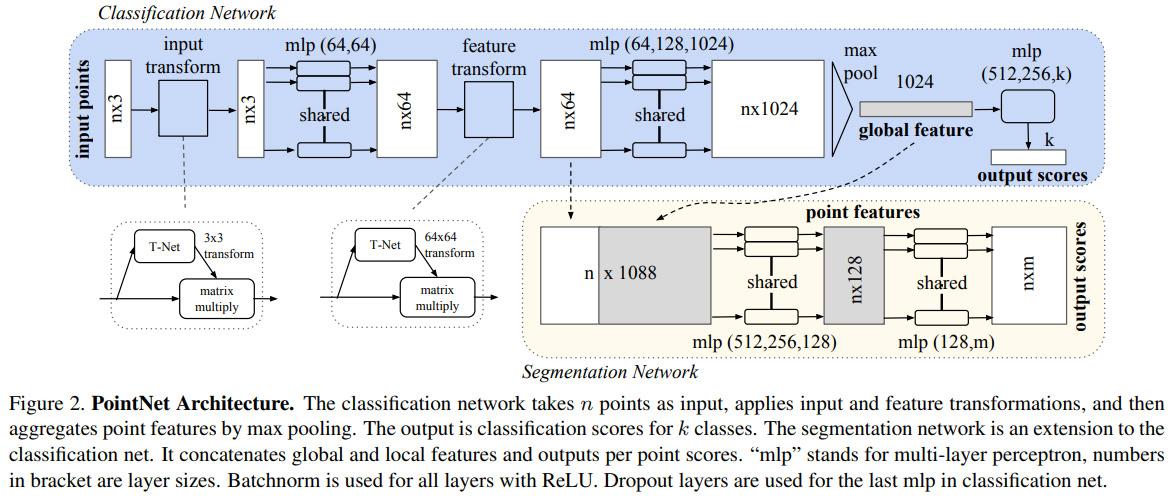

The idea behind the PointNet model is to apply layers invariant to permutations of points.

At the very beginning, a rotation is applied to the points, using the matrix obtained by T-Net. The motivation for applying this rotation is that the same object, which has been rotated differently in space, can be passed to the input of the model. But regardless of this rotation, we want the model to produce similar predictions. Therefore, T-Net will attempt to generalize between different orientations of the same object. Whether our motivation is aligned with what T-Net actually learns we will see later.

Then with the help of a shared MLP applied separately to each point (to preserve invariance to permutations) we obtain a local feature. Then another T-Net (but this time returning a 64x64 matrix). Then another shared MLP to get local features. When we have local features for each point we obtain global features of the whole object by max pooling for each feature. Due to max pooling, global features are independent of point permutations. Then we pass global features through MLP and get logits for each class (if we solve the problem of object classification).

The T-Net architecture is a simplified architecture of the whole PointNet: shared MLP to get local features, max pooling to get global features, then MLP that translates global features into $9$ or $64\cdot 64$ numbers forming a matrix. For stability during training, it is advised to initialize T-Net to return identity matrix.

**Bonus**: with the help of PointNet it is possible to solve the problem not only of object classification, but also of part segmentation (which part of the object belongs to which point). In the picture above the architecture for this task corresponds to the light yellow block. Example:

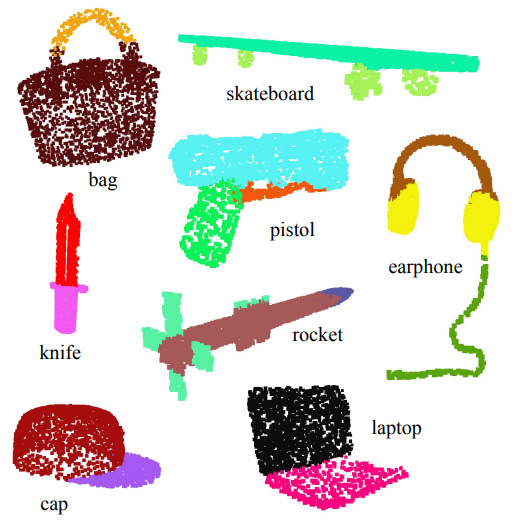

In [26]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

class Tnet(nn.Module):
   def __init__(self, k=3):
      super().__init__()
      self.k=k
      self.conv1 = nn.Conv1d(k,64,1)
      self.conv2 = nn.Conv1d(64,128,1)
      self.conv3 = nn.Conv1d(128,1024,1)
      self.fc1 = nn.Linear(1024,512)
      self.fc2 = nn.Linear(512,256)
      self.fc3 = nn.Linear(256,k*k)

      self.bn1 = nn.BatchNorm1d(64)
      self.bn2 = nn.BatchNorm1d(128)
      self.bn3 = nn.BatchNorm1d(1024)
      self.bn4 = nn.BatchNorm1d(512)
      self.bn5 = nn.BatchNorm1d(256)


   def forward(self, input):
      # input.shape == (bs,n,3)
      bs = input.size(0)
      xb = F.relu(self.bn1(self.conv1(input)))
      xb = F.relu(self.bn2(self.conv2(xb)))
      xb = F.relu(self.bn3(self.conv3(xb)))
      pool = nn.MaxPool1d(xb.size(-1))(xb)
      flat = nn.Flatten(1)(pool)
      xb = F.relu(self.bn4(self.fc1(flat)))
      xb = F.relu(self.bn5(self.fc2(xb)))

      #initialize as identity
      init = torch.eye(self.k, requires_grad=True).repeat(bs,1,1)
      if xb.is_cuda:
        init=init.cuda()
      matrix = self.fc3(xb).view(-1,self.k,self.k) + init
      return matrix


class Transform(nn.Module):
   def __init__(self):
        super().__init__()
        self.input_transform = Tnet(k=3)
        self.feature_transform = Tnet(k=64)
        self.conv1 = nn.Conv1d(3,64,1)

        self.conv2 = nn.Conv1d(64,128,1)
        self.conv3 = nn.Conv1d(128,1024,1)


        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

   def forward(self, input):
        matrix3x3 = self.input_transform(input)
        # batch matrix multiplication
        xb = torch.bmm(torch.transpose(input,1,2), matrix3x3).transpose(1,2)

        xb = F.relu(self.bn1(self.conv1(xb)))

        matrix64x64 = self.feature_transform(xb)
        xb = torch.bmm(torch.transpose(xb,1,2), matrix64x64).transpose(1,2)

        xb = F.relu(self.bn2(self.conv2(xb)))
        xb = self.bn3(self.conv3(xb))
        xb = nn.MaxPool1d(xb.size(-1))(xb)
        output = nn.Flatten(1)(xb)
        return output, matrix3x3, matrix64x64

class PointNet(nn.Module):
    def __init__(self, classes = 10):
        super().__init__()
        self.transform = Transform()
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, classes)


        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.3)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, input):
        xb, matrix3x3, matrix64x64 = self.transform(input)
        xb = F.relu(self.bn1(self.fc1(xb)))
        xb = F.relu(self.bn2(self.dropout(self.fc2(xb))))
        output = self.fc3(xb)
        return self.logsoftmax(output), matrix3x3, matrix64x64

In [27]:
def pointnetloss(outputs, labels, m3x3, m64x64, alpha = 0.0001):
    criterion = torch.nn.NLLLoss()
    bs=outputs.size(0)
    id3x3 = torch.eye(3, requires_grad=True).repeat(bs,1,1)
    id64x64 = torch.eye(64, requires_grad=True).repeat(bs,1,1)
    if outputs.is_cuda:
        id3x3=id3x3.cuda()
        id64x64=id64x64.cuda()
    # We want orthogonality to preserve distances and angles, which is critical for invariance to rotations/scaling.
    diff3x3 = id3x3-torch.bmm(m3x3,m3x3.transpose(1,2))
    diff64x64 = id64x64-torch.bmm(m64x64,m64x64.transpose(1,2))
    return criterion(outputs, labels) + alpha * (torch.norm(diff3x3)+torch.norm(diff64x64)) / float(bs)

## Training loop

In [28]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [29]:
pointnet = PointNet().to(device)
optimizer = torch.optim.Adam(pointnet.parameters(), lr=0.001)

In [30]:
def train(model, train_loader, val_loader=None,  epochs=15, save=True):
    for epoch in tqdm(range(epochs)):
        pointnet.train()
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data['pointcloud'].to(device).float(), data['category'].to(device)
            optimizer.zero_grad()
            outputs, m3x3, m64x64 = pointnet(inputs.transpose(1,2))

            loss = pointnetloss(outputs, labels, m3x3, m64x64)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 10 == 9:    # print every 10 mini-batches
                    print('[Epoch: %d, Batch: %4d / %4d], loss: %.3f' %
                        (epoch + 1, i + 1, len(train_loader), running_loss / 10))
                    running_loss = 0.0

        pointnet.eval()
        correct = total = 0

        # validation
        if val_loader:
            with torch.no_grad():
                for data in val_loader:
                    inputs, labels = data['pointcloud'].to(device).float(), data['category'].to(device)
                    outputs, __, __ = pointnet(inputs.transpose(1,2))
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            val_acc = 100. * correct / total
            print('Valid accuracy: %d %%' % val_acc)

        # save the model
        if save:
            torch.save(pointnet.state_dict(), "save_"+str(epoch)+".pth")

In [31]:
# train(pointnet, train_loader, valid_loader, save=False)

## Test

We are going to use a pretrained model from [here](https://drive.google.com/open?id=1nDG0maaqoTkRkVsOLtUAR9X3kn__LMSL).

In [32]:
import gdown

gdown.download(
    'https://drive.google.com/file/d/1FokXSAIIK-uj9QkGmSevIQJKE_-TvK8h/view?usp=drive_link',
    'checkpoint.pth', quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1FokXSAIIK-uj9QkGmSevIQJKE_-TvK8h
To: /content/checkpoint.pth
100%|██████████| 13.9M/13.9M [00:00<00:00, 246MB/s]


'checkpoint.pth'

In [33]:
pointnet = PointNet()
pointnet.to(device)
pointnet.load_state_dict(torch.load('checkpoint.pth', weights_only=False, map_location=device))
pointnet.eval()

PointNet(
  (transform): Transform(
    (input_transform): Tnet(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (feature_transform): Tnet(
      (conv1): Conv1d(64, 64, kernel_size=(1,

Let us verify that the trained first T-Net (generating a 3x3 matrix) is consistent with our intuition and tries to deal with the fact that it may be given the same object that is rotated differently as input.

In [34]:
seed_everything(0)

def create_scatter_fig(xs,ys,zs):
    data=[go.Scatter3d(x=xs, y=ys, z=zs,
                                   mode='markers')]
    fig = visualize_rotate(data)
    fig.update_traces(marker=dict(size=2,
                      line=dict(width=2,
                      color='DarkSlateGrey')),
                      selector=dict(mode='markers'))
    return fig

num_examples = 5

fig_list_before_tnet = []
fig_list_after_tnet = []

with open(os.path.join(data_path, "toilet/train/toilet_0001.off"), 'r') as f:
        verts, faces = read_off(f)
        for i in range(num_examples):
            pc = PointSampler(1024)((verts, faces))
            pc = RandRotation_z()(pc)
            fig = create_scatter_fig(*pc.T)
            fig_list_before_tnet.append(fig)

            # rotate using T-Net
            pc = torch.tensor(pc).to(device).float().unsqueeze(0)
            matrix3x3 = pointnet.transform.input_transform(torch.transpose(pc,1,2))
            pc2 = torch.bmm(pc, matrix3x3).detach()[0].cpu()
            fig = create_scatter_fig(*pc2.T)
            fig_list_after_tnet.append(fig)

fig = make_subplots(
    rows=2,
    cols=num_examples,
    specs=[
        [{'type': 'scene'}] * num_examples,
        [{'type': 'scene'}] * num_examples
    ],
    subplot_titles=[f'Rotated toilet {i+1}' for i in range(num_examples)] + [f'Toilet {i+1} after T-Net' for i in range(num_examples)],
)

fig_list = fig_list_before_tnet + fig_list_after_tnet
for idx, sub_fig in enumerate(fig_list):
    row = (idx // 5) + 1
    col = (idx % 5) + 1

    for trace in sub_fig.data:
        fig.add_trace(trace, row=row, col=col)

fig.update_layout(height=800, width=1500)
fig.show()

Indeed, we can see that the objects in columns 1, 2 and 4 became very similar to each other after applying the first T-Net.

But wait, why is it that after applying T-Net, the coordinates are on a scale of thousands, and the toilet itself seems to be flattened??? As you remember, we added a special regularization on making the rotation matrix orthogonal. Why did this happen?

Let us check the matrix obtained by T-Net for orthogonality.

In [35]:
with open(os.path.join(data_path, "toilet/train/toilet_0001.off"), 'r') as f:
    verts, faces = read_off(f)
    pc = PointSampler(1024)((verts, faces))

pc = torch.tensor(pc).to(device).float().unsqueeze(0)
matrix3x3 = pointnet.transform.input_transform(torch.transpose(pc,1,2))
print(matrix3x3)
print(torch.norm(torch.bmm(matrix3x3,matrix3x3.transpose(1,2))))

tensor([[[-113.7205,   84.0211,   29.3396],
         [ -47.3015,   70.5892,   59.0142],
         [  68.8357, -165.1878,  183.2604]]], grad_fn=<AddBackward0>)
tensor(75902.6250, grad_fn=<LinalgVectorNormBackward0>)


The matrix is far from orthogonal, to put it mildly.

In general, this is not surprising since the regularization factor was set to $10^{-4}$ during training.

There's no certainty, but it's more likely that such a coefficient just gave a better score on validation, so the authors of the paper left it in, omitting their initial motivation for orthogonality.

In [36]:
all_preds = []
all_labels = []
with torch.no_grad():
    for data in tqdm(valid_loader):

        inputs, labels = data['pointcloud'].float().to(device), data['category']
        outputs, __, __ = pointnet(inputs.transpose(1,2))
        _, preds = torch.max(outputs.data, 1)
        all_preds += list(preds.cpu().numpy())
        all_labels += list(labels.numpy())

  0%|          | 0/15 [00:00<?, ?it/s]

In [37]:
cm = confusion_matrix(all_labels, all_preds);
cm

array([[41,  9,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1, 96,  2,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  1, 99,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  2,  2, 32,  5,  0, 18,  5, 20,  1],
       [ 0,  0,  0,  0, 41,  0, 44,  0,  1,  0],
       [ 0,  0,  1,  0, 23, 73,  2,  1,  0,  0],
       [ 0,  0,  1,  0,  5,  0, 79,  0,  1,  0],
       [ 0,  1,  1,  0,  1,  0,  1, 96,  0,  0],
       [ 0,  0,  0,  4,  0,  0,  1,  0, 95,  0],
       [ 1,  0, 13,  0,  1,  0,  2,  1,  0, 82]])

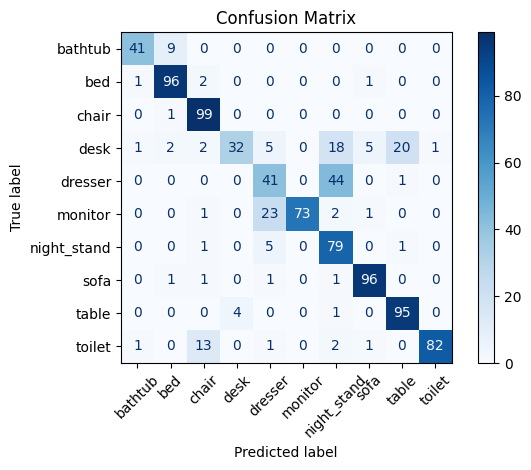

In [38]:
class_names = classes.keys()

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Layers from Vector Neurons


We are not going to implement [Vector Neurons](https://arxiv.org/abs/2104.12229) PointNet, but only some parts of it. We will also show their properties.

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

Let's write down some formal definitions.

**Invariance**: A function $f: \mathcal{X} \to \mathcal{Y}$ is called **invariant** under a group action $G$ on $\mathcal{X}$ if for all transformations $T_g \in G$ and all inputs $x \in \mathcal{X}$:

$$ f(T_g \cdot x) = f(x) $$

This means the output remains **unchanged** when the input is transformed by any group element $g \in G$.



**Equivariance**:

A function $f: \mathcal{X} \to \mathcal{Y}$ is called **equivariant** under a group $G$ if there exist actions of $G$ on both $\mathcal{X}$ and $\mathcal{Y}$ such that for all $T_g \in G$ and $x \in \mathcal{X}$:

$$f(T_g \cdot x) = T'_g \cdot f(x)$$

where $T_g$ represents the group action on $\mathcal{X}$, $\space$ $T'_g$ represents the corresponding group action on $\mathcal{Y}$ (often $T'_g = T_g$ or a related representation).

This means the transformation of the input **commutes** with the transformation of the output.

We want to achieve equivariance property for the layers ([SO(3) group](https://en.wikipedia.org/wiki/3D_rotation_group)).

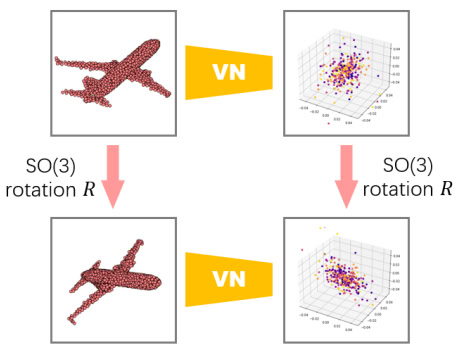

Typical neural networks today are built with “scalar” neurons – where the output of the nonlinearities in a given layer is an ordered list of scalars. We extend deep networks to allow for “vector” neurons – where the output of the non-linearity is an ordered list of vectors.

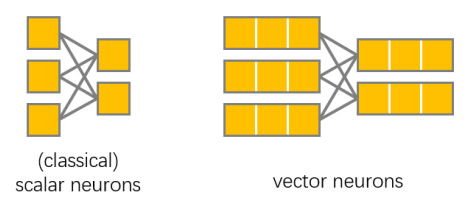

### Vector Neurons Linear Layer (equivariant)

The object is presented as $\mathcal{V} \in \mathbb{R}^{n \times C \times 3}$, where $n$ is the number of points and each point consists of $C$ channels of $3$-dimensional vectors. Initially $C=1$ and each point is represented as $(x,y,z)$ coordinates.

Let's consider one point $\mathbf{V} \in \mathbb{R}^{C \times 3}$. Our linear transformation will be given by the matrix $\mathbf{W} \in \mathbb{R}^{C' \times C}$.

$$ \mathbf{V'} = f_{\texttt{lin}}(\mathbf{V}; \mathbf{W}) = \mathbf{W} \mathbf{V} \in \mathbb{R}^{C' \times 3} $$

Let's verify that a rotation matrix $R \in SO(3)$ commutes with this linear layer:

$$ f_{\texttt{lin}}(\mathbf{V} R; \mathbf{W}) = \mathbf{W} \mathbf{V} R = f_{\texttt{lin}}(\mathbf{V}; \mathbf{W}) R = \mathbf{V'}R $$

In [40]:
class VNLinear(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.linear = nn.Linear(in_channels, out_channels, bias=False)

    def forward(self, x):
        """
        in: [batch, in_channels, 3]
        out: [batch, out_channels, 3]
        """
        assert self.in_channels == x.size(1)
        batch_size = x.size(0)
        x = x.permute(0, 2, 1)     # [batch, 3, in_channels] - to process 3d vectors as a single unit
        x = self.linear(x)         # [batch, 3, out_channels]
        return x.permute(0, 2, 1)  # [batch, out_channels, 3]

Now let us check that the rotation matrix commutes with the linear layer in practice.

In [41]:
def gen_orthogonal(n):
    A = torch.randn(n, n)
    Q, R = torch.linalg.qr(A)
    assert (Q @ Q.T - torch.eye(n)).max() < 1e-4
    return Q

In [42]:
for _ in range(1000):
    x = torch.randn(1, 2, 3)

    Q = gen_orthogonal(3)

    vn_layer = VNLinear(in_channels=2, out_channels=2)

    output = vn_layer(x)
    x_rot = x @ Q

    assert (output @ Q - vn_layer(x_rot)).max() / (output @ Q).abs().mean() < 1e-3

### Vector Neurons ReLU (equivariant)

We still want equivariance property for the activation that take into account its geometry.

Idea: *to truncate the part of a vector pointing into the negative half-space of the direction under study.*

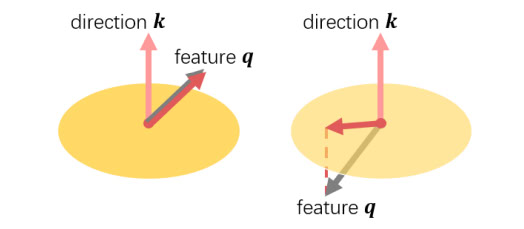

However, the choice of this direction should also ensure equivariance. So let's choose the direction as a linear transformation of the channels of entry point.

More formally, given an input vector-list feature $\mathbf{V} \in \mathbb{R}^{C \times 3}$, for each output vector-neuron $\mathbf{v'} \in \mathbf{V'}$ we learn two weight matrices $\mathbf{W} ∈ \mathbb{R}^{1\times C}$ and $\mathbf{U} ∈ \mathbb{R}^{1\times C}$, linearly mapping the input feature $\mathbf{V}$ to a feature $\mathbf{q} \in \mathbb{R}^{1 \times 3}$ and a direction $\mathbf{k} \in \mathbb{R}^{1 \times 3}$:

$$ \mathbf{q}=\mathbf{W}\mathbf{V}, \ \ \mathbf{k}=\mathbf{U}\mathbf{V} $$

We then define the output VN as:

$$ \mathbf{v'} = \begin{cases}
\mathbf{q}, & \text{if } \langle \mathbf{q}, \mathbf{k} \rangle \geq 0 \\
\mathbf{q} - \left\langle \mathbf{q}, \frac{\mathbf{k}}{\|\mathbf{k}\|} \right\rangle \frac{\mathbf{k}}{\|\mathbf{k}\|}, & \text{otherwise,}
\end{cases}
$$

resulting in an output vector-list: $ f_{\texttt{ReLU}}(\mathbf{V})=[\mathbf{v'}]_{c=1}^C $

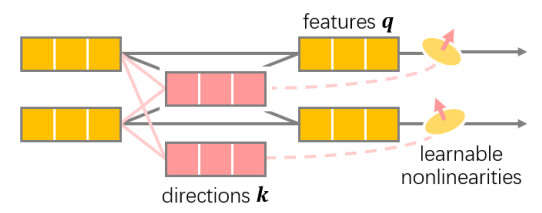

In [43]:
class VNReLU(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.W = nn.Linear(in_channels, in_channels, bias=False)  # for q component
        self.U = nn.Linear(in_channels, in_channels, bias=False)  # for k component

    def forward(self, x):
        """
        in: [batch, in_channels, 3]
        out: [batch, out_channels, 3]
        """
        assert self.in_channels == x.size(1)
        batch_size = x.size(0)

        x = x.permute(0, 2, 1)
        q = self.W(x).permute(0, 2, 1) # - main vector to which the nonlinearity will be applied
        k = self.U(x).permute(0, 2, 1) # - non-linearity direction

        k_norm = F.normalize(k, p=2, dim=-1) # - we need only direction, not its value

        dot_prod = (q * k_norm).sum(dim=-1, keepdim=True) # - how q "is aligned" with the direction k_norm

        # dot_prod < 0 => we remove the component q that lies along the direction k
        mask = (dot_prod >= 0).float()
        v_prime = mask * q + (1 - mask) * (q - dot_prod * k_norm)

        return v_prime

In [44]:
for _ in range(1000):
    x = torch.randn(1, 2, 3)

    Q = gen_orthogonal(3)

    vn_relu = VNReLU(in_channels=2)

    output = vn_relu(x)
    x_rot = x @ Q

    assert (output @ Q - vn_relu(x_rot)).max() / (output @ Q).abs().mean() < 1e-3

### Vector Neurons MaxPool (equivariant)

Pooling is widely used when aggregating local/global neighbourhood information. While mean pooling is a linear operation that respects rotation equivariance, we also define a VN max pooling layer as a counterpart to the classical max pooling on scalars.

For global pooling, we are given a set of vector-lists $\mathcal{V} \in \mathbb{R}^{n \times C \times 3}$. We learn an element-wise signal of data dependent directions $\mathcal{K} \in \mathbb{R}^{n \times C \times 3}$. Similarly to VN ReLU, these directions are obtained via applying a weight matrix $\mathbf{W} \in \mathbb{R}^{C \times C}$ to each $\mathbf{V}_n \in \mathcal{V}$:

$$ \mathcal{K} = \{ \mathbf{W} \mathbf{V}_n \}_{n=1}^N $$

and then computing the element of $\mathcal{V}$ that best aligns with $\mathcal{K}$ and selecting it as our global feature: for each channel $c \in [C]$,

$$ f_{\texttt{MAX}} (\mathcal{V})[c] = \mathbf{V}_{n^*} [c] $$
$$ \text{where} \ \ n^*(c) = \text{argmax}_n \langle \mathbf{W} \mathbf{V}_n [c], \mathbf{V}_n [c] \rangle $$

where $\mathbf{V}_n[c]$ stands for the vector channel $\mathbf{v}_c \in \mathbf{V}_n$.

We do not take the maximum over coordinates; instead, we select the vector that is best aligned with its corresponding direction.

In [45]:
class VNMaxPool(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.W = nn.Linear(in_channels, in_channels, bias=False)  # for data dependent directions

    def forward(self, x):
        """
        in: [batch, in_channels, 3]
        out: [in_channels, 3]
        """
        assert self.in_channels == x.size(1)
        batch_size = x.size(0)

        K = self.W(x.permute(0, 2, 1)).permute(0, 2, 1) # - max pooling directions
        scalar_prod = torch.sum(K * x, dim=2)

        assert scalar_prod.shape == (batch_size, self.in_channels)

        n_star_c = torch.argmax(scalar_prod, dim=0)

        return x[n_star_c, torch.arange(self.in_channels)]

Let's verify that the rotation matrix commutes with our VN max pooling layer.

In [46]:
for _ in range(1000):
    x = torch.randn(10, 6, 3)

    Q = gen_orthogonal(3)

    vn_max_pool = VNMaxPool(in_channels=6)

    output = vn_max_pool(x)
    x_rot = x @ Q

    assert (output @ Q - vn_max_pool(x_rot)).max() / (output @ Q).abs().mean() < 1e-3

Also, let's create a network from the available layers and check commutativity with a rotation matrix on it.

In [47]:
class VNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = VNLinear(5, 3)
        self.relu1 = VNReLU(3)
        self.linear2 = VNLinear(3, 10)
        self.relu2 = VNReLU(10)

        self.max_pool = VNMaxPool(10)

        self.linear3 = VNLinear(10, 5)
        self.relu3 = VNReLU(5)

    def forward(self, x):
        out = self.relu2(self.linear2(self.relu1(self.linear1(x))))
        out = self.max_pool(out).unsqueeze(0)
        return self.relu3(self.linear3(out))


In [48]:
for _ in range(1000):
    x = torch.randn(10, 5, 3)

    Q = gen_orthogonal(3)

    vnn = VNN()

    output = vnn(x)
    x_rot = x @ Q

    assert (output @ Q - vnn(x_rot)).max() / (output @ Q).abs().mean() < 1e-3

### Vector Neurons BatchNorm (equivariant)

In contrast to other forms of normalizations, batch normalization aggregates statistics across all batch samples. While technically possible, in the context of rotation equivariant networks, averaging across arbitrarily rotated inputs would not necessarily be meaningful. For example, averaging two input features rotated in opposite directions would zero them out instead of producing that feature in a canonical pose.

We instead apply batch normalization to the invariant component of the vector-list features, by normalizing the $2$-norms of the vector-list features.

The intuition behind this is as follows. The length of a vector is invariant to rotation, so we can multiply and divide by it.

Given a batch of $B$ vector-list features $\{\mathbf{V}_b \}_{b=1}^B$ with each $\mathbf{V}_b \in \mathbb{R}^{C \times 3}$, our batch normalization is defined as:

$$ \mathbf{N}_b = \text{ElementwiseNorm}(\mathbf{V}_b) \in \mathbb{R}^{N \times 1} $$

$$ \{ \mathbf{N}'_b \}_{b=1}^B = \text{BatchNorm}(\{ \mathbf{N}_b \}_{b=1}^B) $$
$$ \mathbf{V}'_b[c] = \mathbf{V}_b[c] \frac{\mathbf{N}'_b[c]}{\mathbf{N}_b[c]}, \ \ \forall c \in [C] $$


where $\mathbf{V}'_b[c]$, $\mathbf{V}_b[c]$ are the vector channels, $\mathbf{N}'_b[c]$, $\mathbf{N}_b[c]$ are their scalar $2$-norms, and $\text{ElementwiseNorm}(\mathbf{V}_b)$ computes the $2$-norm of every vector channel $\mathbf{v}_c = \mathbf{V}_b[c] \in \mathbf{V}_b$.

In [49]:
EPS = 1e-6

class VNBatchNorm(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.num_features = num_features
        self.bn = nn.BatchNorm1d(self.num_features)

    def forward(self, x):
        assert(x.size(1) == self.num_features)

        norm = torch.norm(x, dim=2) + EPS
        norm_bn = self.bn(norm)

        norm = norm.unsqueeze(2)
        norm_bn = norm_bn.unsqueeze(2)
        x = x / norm * norm_bn

        return x

Finally let's check that the rotation matrix commutes with our BatchNorm layer.

This check will be a bit more complicated than for all previous layers because we must first accumulate the running mean and variance.

The general setup of the experiment is as follows. We have several batches of objects. We need to check that the running mean and variance of the batchnorm layer is invariant to rotations, and that the batchnorm layer itself is equivariant. To do this, we run all the batches through the model 2 times. The first time without rotations. The second time we apply a different random rotation to each batches (indeed, we can apply it to each object separately). Then we check that the output of the last batch for the first run after applying the rotation that was applied to the last batch in the second run is the same as the output of the last batch in the second run.

In [50]:
class VNN_with_BatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = VNLinear(2, 3)
        self.relu1 = VNReLU(3)
        self.bn1 = VNBatchNorm(3)
        self.linear2 = VNLinear(3, 10)
        self.relu2 = VNReLU(10)
        self.bn2 = VNBatchNorm(10)

        self.max_pool = VNMaxPool(10)

        self.linear3 = VNLinear(10, 5)
        self.relu3 = VNReLU(5)

    def forward(self, x):
        out = self.bn2(self.relu2(self.linear2(self.bn1(self.relu1(self.linear1(x))))))
        out = self.max_pool(out).unsqueeze(0)
        return self.relu3(self.linear3(out))

In [51]:
for _ in range(100):
    Q = gen_orthogonal(3)

    xs = []

    rnd_seed = random.randint(1, 179179)

    seed_everything(rnd_seed) # we need to fix seed so that both models are initialized with the same weights
    vnn = VNN_with_BatchNorm()
    vnn.train()
    for i in range(10):
        x = torch.randn(10, 2, 3)
        xs.append(x.clone())
        x = vnn(x)
    vnn.eval()
    x_final = torch.randn(10, 2, 3)
    output = vnn(x_final)

    seed_everything(rnd_seed) # set the same seed as for the previous model
    vnn = VNN_with_BatchNorm()
    vnn.train()
    for i in range(10):
        Q2 = gen_orthogonal(3)
        x = xs[i] @ Q2 # we can choose different rotation matrices for different objects
        x = vnn(x)
    vnn.eval()
    output_rot = vnn(x_final @ Q)

    assert (output @ Q - output_rot).max() / (output @ Q).abs().mean() < 1e-2

### Vector Neurons Invariant layers

We've implemented some equivariant layers, which is cool, but it's not clear why we need it at all yet. Even if we build an equivariant neural network, its output will depend on the rotation, which we don't know.  We want the model to produce the same output on the same object regardless of the rotation.

Invariant layers will help us to cope with this situation. If our model consists of many equivariant layers followed by one invariant layer, the whole model will be invariant!



Key to our approach is the idea that the product of an equivariant signal $\mathbf{V} \in \mathbb{R}^{C \times 3}$ by the transpose of an equivariant signal $\mathbf{T} \in \mathbb{R}^{C' \times 3}$
is rotation invariant:
$$ (\mathbf{V} R)(\mathbf{T} R)^T = \mathbf{V} R R^T \mathbf{T}^T = \mathbf{V} \mathbf{T}^T $$

We could compute an invariant feature from a vector-list $\mathbf{V} \in \mathbb{R}^{C \times 3}$ as the Gram matrix $\mathbf{V} \mathbf{V}^T$. However, this would result in a large $O(C^2)$ storage complexity. We could also consider taking the norm of each row of $\mathbf{V}$ but this would result in the loss of the relative directional information between the rows.

Instead  we produce a matrix $\mathbf{T}_n$ for each element by concatenating its feature $\mathbf{V}_n \in \mathbb{R}^{C \times 3}$ with the global mean $\overline{\mathbf{V}} := \frac{1}{N} \sum_n \mathbf{V}_n \in \mathbb{R}^{C \times 3}$ and running through a vector neuron MLP with a target number of channel $C' = 3$:

$$ \mathbf{T}_n := \texttt{VN-MLP}([\mathbf{V}_n, \overline{\mathbf{V}}]) $$

Finally we define our invariant layer by

$$ \texttt{VN-In}(\mathbf{V}_n) := \mathbf{V}_n \mathbf{T}_n^T $$

In [55]:
class VN_mlp(nn.Module):
    def __init__(self, num_features, out_features):
        super().__init__()
        self.mlp = nn.Sequential(VNLinear(num_features, num_features * 2),
                                  VNReLU(num_features * 2),
                                  VNLinear(num_features * 2, out_features),
                                  VNReLU(out_features)
                                 )
    def forward(self, x):
        return self.mlp(x)


class VN_Invariant(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.mlp =  VN_mlp(num_features + 1, 3)

    def forward(self, x):
        x_mean = torch.mean(x, dim=1).unsqueeze(1)
        T_in = torch.concat([x, x_mean], dim=1)       # [B, C+1, 3]
        T = self.mlp(T_in)
        return torch.bmm(x, T.transpose(1, 2))

Let's build a neural network and test it for invariance!

In [56]:
class VNN_invariant(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = VN_mlp(2, 5)
        self.invariant_layer = VN_Invariant(5)

    def forward(self, x):
        return self.invariant_layer(self.mlp(x))

In [57]:
for _ in range(1000):
    x = torch.randn(4, 2, 3)

    Q = gen_orthogonal(3)

    vnn = VNN_invariant()
    x_rot = x @ Q

    assert (vnn(x) - vnn(x_rot)).max() / output.abs().mean() < 1e-2